In [1]:
import os
import random
import numpy as np
import torch
from torch import nn, Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Import common utilities from HTB Evasion Library
from htb_ai_library import (
    set_reproducibility,
    SimpleCNN,
    get_mnist_loaders,
    mnist_denormalize,
    train_model,
    evaluate_accuracy
)

# Configure reproducibility
set_reproducibility(1337)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# Prepare data loaders using library function (normalized space)
train_loader, test_loader = get_mnist_loaders(batch_size=128, normalize=True)

# Initialize model using library's SimpleCNN
model = SimpleCNN().to(device)


# Train the model using library function
trained_model = train_model(model, train_loader, test_loader, epochs=1, device=device)

# Evaluate baseline accuracy using library function
baseline_acc = evaluate_accuracy(trained_model, test_loader, device)
print(f"Baseline test accuracy: {baseline_acc:.2f}%")

Epoch 1/1: Avg Loss = 0.1567, Test Accuracy = 98.37%
Baseline test accuracy: 98.37%


In [10]:
####################################################################################################
#RUNS MODEL IN SAFE EVALUATION MODE AND COMPUTES PREDICTION AND LOSS NEEDED FOR ADVERSERIAL GRADIENT
####################################################################################################


def _forward_and_loss(model: nn.Module, x: Tensor, y: Tensor) -> tuple[Tensor, Tensor]:
    """Forward pass and cross-entropy loss without side effects.

    Args:
        model: Neural network classifier
        x: Input images tensor
        y: Target labels tensor

    Returns:
        tuple[Tensor, Tensor]: Model logits and scalar loss value
    """
    if getattr(model, "training", False):
        raise RuntimeError("Expected model.eval() for attack computations to avoid BN/Dropout state updates")
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    return logits, loss

In [11]:
#####################################################
# CACULATES GRADIENT OF LOSS WITH RESPECT TO AN IMAGE
#####################################################

def _input_gradient(model: nn.Module, x: Tensor, y: Tensor) -> Tensor:
    """Return gradient of loss with respect to input tensor x.

    Args:
        model: Neural network in evaluation mode
        x: Input images to compute gradients for
        y: True labels for loss computation

    Returns:
        Tensor: Gradient tensor with same shape as x
    """
    x_req = x.clone().detach().requires_grad_(True)
    _, loss = _forward_and_loss(model, x_req, y)
    model.zero_grad(set_to_none=True)
    loss.backward()
    return x_req.grad.detach()


In [12]:
######################################
# CORE IMPLEMENTATION
######################################

def fgsm_attack(model: nn.Module,
                images: Tensor,
                labels: Tensor,
                epsilon: float,
                targeted: bool = False) -> Tensor:

    # Valid normalized range for MNIST
    MNIST_NORM_MIN = (0.0 - 0.1307) / 0.3081
    MNIST_NORM_MAX = (1.0 - 0.1307) / 0.3081

    if epsilon < 0:
        raise ValueError("epsilon must be non-negative")
    if not images.is_floating_point():
        raise ValueError("images must be floating point tensors")
    # Gets input gradients
    grad = _input_gradient(model, images, labels)
    # Chooses attack type ie Targetted or Untargetted
    step_dir = -1.0 if targeted else 1.0
    # Creates adversarial image
    x_adv = images + step_dir * epsilon * grad.sign()
    # Normalizes Adverserial image
    x_adv = torch.clamp(x_adv, MNIST_NORM_MIN, MNIST_NORM_MAX)
    return x_adv.detach()


In [13]:
#########################################################
# Pixel Space Varient OF FGSM
#########################################################

# This function turns the mean and std lists into tensors shaped so they can be broadcast across every pixel in every image
# Helper Fuction so that pytorch can apply normalization channels without errors.
def _norm_params(images: Tensor, mean: list, std: list) -> tuple[Tensor, Tensor]:
    """Convert normalization parameters to broadcastable tensors.

    Args:
        images: Input images tensor with shape (N, C, H, W)
        mean: Normalization mean per channel as list
        std: Normalization std per channel as list

    Returns:
        tuple[Tensor, Tensor]: Mean and std tensors with shape (1, C, 1, 1)
    """
    device, dtype, C = images.device, images.dtype, images.shape[1]
    mean_t = torch.tensor(mean, device=device, dtype=dtype).view(1, -1, 1, 1)
    std_t = torch.tensor(std, device=device, dtype=dtype).view(1, -1, 1, 1)
    if mean_t.shape[1] != C or std_t.shape[1] != C:
        raise ValueError("mean/std channels must match images")
    return mean_t, std_t





def fgsm_pixel_space(model: nn.Module,
                     images: Tensor,
                     labels: Tensor,
                     epsilon: float,
                     mean: list,
                     std: list,
                     targeted: bool = False) -> Tensor:
    """FGSM for pixel-space inputs attacking normalized models.

    This variant accepts images in [0,1] pixel space rather than normalized
    space. It normalizes inputs internally for the model, converts gradients
    back to pixel space, and returns adversarials in [0,1] pixel space.

    Args:
        model: Model expecting normalized inputs
        images: Clean images in [0,1] pixel space (unnormalized)
        labels: Target labels
        epsilon: Max perturbation in pixel space (e.g., 8/255)
        mean: Normalization mean per channel
        std: Normalization std per channel
        targeted: If True, minimize loss towards labels

    Returns:
        Tensor: Adversarial images in [0,1] pixel space (unnormalized)
    """
    mean_t, std_t = _norm_params(images, mean, std)
    x = images.clone().detach()
    x_norm = (x - mean_t) / std_t
    x_norm.requires_grad_(True)

    _, loss = _forward_and_loss(model, x_norm, labels)
    model.zero_grad(set_to_none=True)
    loss.backward()

    # Convert gradient from normalized space to image space
    grad_img = x_norm.grad / std_t
    step_dir = -1.0 if targeted else 1.0
    x_adv = torch.clamp(x + step_dir * epsilon * grad_img.sign(), 0.0, 1.0)
    return x_adv.detach()





    

In [14]:
###################################
# EVALUATION
###################################


from typing import Dict

def evaluate_attack(model: nn.Module,
                   clean_images: Tensor,
                   adversarial_images: Tensor,
                   true_labels: Tensor) -> Dict[str, float]:
    """Compute accuracy, success rate, confidence shift, and norms.

    Args:
        model: Evaluated classifier in evaluation mode
        clean_images: Clean inputs in the model's expected domain (e.g., normalized MNIST)
        adversarial_images: Adversarial counterparts in the same domain as `clean_images`
        true_labels: Ground-truth labels

    Returns:
        Dict[str, float]: Aggregated metrics summarizing attack impact
    """
    model.eval()
    with torch.no_grad():
        clean_logits = model(clean_images)
        adv_logits = model(adversarial_images)

        clean_probs = F.softmax(clean_logits, dim=1)
        adv_probs = F.softmax(adv_logits, dim=1)

        clean_pred = clean_logits.argmax(dim=1)
        adv_pred = adv_logits.argmax(dim=1)


        clean_correct = (clean_pred == true_labels)
        adv_correct = (adv_pred == true_labels)

        originally_correct = clean_correct
        flipped = (~adv_correct) & originally_correct



        conf_clean = clean_probs.gather(1, true_labels.view(-1, 1)).squeeze(1)
        conf_adv = adv_probs.gather(1, true_labels.view(-1, 1)).squeeze(1)



        l2 = (adversarial_images - clean_images).view(clean_images.size(0), -1).norm(p=2, dim=1)
        linf = (adversarial_images - clean_images).abs().amax()

        return {
            "clean_accuracy": clean_correct.float().mean().item(),
            "adversarial_accuracy": adv_correct.float().mean().item(),
            # Success rate among originally correct samples only
            "attack_success_rate": (
                flipped.float().sum() / originally_correct.float().sum().clamp_min(1.0)
            ).item(),
            "avg_clean_confidence": conf_clean.mean().item(),
            "avg_adv_confidence": conf_adv.mean().item(),
            "avg_confidence_drop": (conf_clean - conf_adv).mean().item(),
            "avg_l2_perturbation": l2.mean().item(),
            "max_linf_perturbation": linf.item(),
        }



In [15]:
###################################
# VISUALIZATION
###################################


import matplotlib.pyplot as plt
import numpy as np

# Colors imported from library
from htb_ai_library import (
    HTB_GREEN, NODE_BLACK, HACKER_GREY, WHITE,
    AZURE, NUGGET_YELLOW, MALWARE_RED, VIVID_PURPLE, AQUAMARINE
)

def _style_axes(ax: plt.Axes) -> None:
    """Apply Hack The Box dark theme to an axes instance.

    Args:
        ax: Matplotlib axes to style
    """
    ax.set_facecolor(NODE_BLACK)
    ax.tick_params(colors=HACKER_GREY)
    for spine in ax.spines.values():
        spine.set_color(HACKER_GREY)
    ax.grid(True, color=HACKER_GREY, linestyle="--", alpha=0.25)




def visualize_attack(model: nn.Module,
                    image: Tensor,
                    label: Tensor,
                    make_adv,
                    title: str,
                    num_classes: int = 10,
                    targeted: bool = False,
                    target_class: int | None = None) -> None:
    """HTB-styled visualization for adversarial examples.

    Args:
        model: Classifier in evaluation mode
        image: Single image in normalized space, shape (C,H,W)
        label: Scalar true label tensor
        make_adv: Callable (model, image_batch, label_batch) -> adv_batch in normalized space
        title: Figure title
        num_classes: Number of classes to show in probability bars
        targeted: Whether the attack is targeted
        target_class: Optional target class to annotate
    """
    model.eval()
    dev = next(model.parameters()).device
    image_dev = image.to(dev)
    label_dev = label.to(dev)

    # Compute clean predictions
    with torch.no_grad():
        clean_probs = F.softmax(model(image_dev.unsqueeze(0)), dim=1).squeeze(0)
        clean_pred = int(clean_probs.argmax().item())

    # Generate adversarial example
    x_adv_dev = make_adv(model, image_dev.unsqueeze(0), label_dev.unsqueeze(0)).squeeze(0)
    perturbation_dev = x_adv_dev - image_dev

    # Compute adversarial predictions
    with torch.no_grad():
        adv_probs = F.softmax(model(x_adv_dev.unsqueeze(0)), dim=1).squeeze(0)
        adv_pred = int(adv_probs.argmax().item())

    # Denormalize for visualization
    image_vis = mnist_denormalize(image_dev.unsqueeze(0)).squeeze(0).detach().cpu()
    x_adv_vis = mnist_denormalize(x_adv_dev.unsqueeze(0)).squeeze(0).detach().cpu()
    perturbation_vis = (x_adv_vis - image_vis)


    # Create figure with grid layout
    fig = plt.figure(figsize=(16, 10), facecolor=NODE_BLACK)
    gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.35)

    # Original image panel
    ax1 = fig.add_subplot(gs[0, 0])
    _style_axes(ax1)
    if image_vis.shape[0] == 1:
        ax1.imshow(image_vis.squeeze(0), cmap='gray', vmin=0, vmax=1)
    else:
        ax1.imshow(image_vis.permute(1, 2, 0))
    ax1.set_title(f"Original | class={clean_pred} | p={clean_probs[clean_pred]:.2%}",
                  color=HTB_GREEN, fontweight="bold")
    ax1.set_xticks([])
    ax1.set_yticks([])

    # Adversarial image panel
    ax2 = fig.add_subplot(gs[0, 1])
    _style_axes(ax2)
    if x_adv_vis.shape[0] == 1:
        ax2.imshow(x_adv_vis.squeeze(0), cmap='gray', vmin=0, vmax=1)
    else:
        ax2.imshow(x_adv_vis.permute(1, 2, 0))
    title_color = MALWARE_RED if adv_pred != int(label.item()) else HTB_GREEN
    adv_title = f"Adversarial | class={adv_pred} | p={adv_probs[adv_pred]:.2%}"
    if targeted and target_class is not None:
        adv_title += f" | target={target_class}"
    ax2.set_title(adv_title, color=title_color, fontweight="bold")
    ax2.set_xticks([])
    ax2.set_yticks([])


    # Perturbation panel (scaled for visibility)
    ax3 = fig.add_subplot(gs[0, 2])
    _style_axes(ax3)
    pert_scaled = (perturbation_vis * 10 + 0.5).clamp(0, 1)
    if pert_scaled.shape[0] == 1:
        ax3.imshow(pert_scaled.squeeze(0), cmap='gray', vmin=0, vmax=1)
    else:
        ax3.imshow(pert_scaled.permute(1, 2, 0))
    ax3.set_title("Perturbation (x10)", color=NUGGET_YELLOW, fontweight="bold")
    ax3.set_xticks([])
    ax3.set_yticks([])



    # Class probability comparison
    ax4 = fig.add_subplot(gs[1, :])
    _style_axes(ax4)
    x = np.arange(num_classes)
    width = 0.4
    ax4.bar(x - width/2, clean_probs[:num_classes].cpu(), width,
            color=AZURE, label="clean")
    ax4.bar(x + width/2, adv_probs[:num_classes].cpu(), width,
            color=MALWARE_RED, label="adv")
    ax4.set_xlabel("Class", color=WHITE)
    ax4.set_ylabel("Probability", color=WHITE)
    legend = ax4.legend(facecolor=NODE_BLACK, edgecolor=HACKER_GREY)
    for text in legend.get_texts():
        text.set_color(WHITE)
    ax4.set_title("Class probabilities", color=HTB_GREEN, fontweight="bold")
    for text in ax4.get_xticklabels() + ax4.get_yticklabels():
        text.set_color(HACKER_GREY)

    # Add main title and display
    fig.suptitle(title, color=HTB_GREEN, fontweight="bold", fontsize=24, y=0.98)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()



def visualize_fgsm_attack(model: nn.Module,
                         image: Tensor,
                         label: Tensor,
                         epsilon: float,
                         num_classes: int = 10,
                         targeted: bool = False,
                         target_class: int | None = None) -> None:
    """Wrapper for visualize_attack using FGSM.

    Args:
        model: Classifier model
        image: Single image tensor
        label: True label
        epsilon: Perturbation budget
        num_classes: Classes to display
        targeted: If True, targeted attack
        target_class: Target class for targeted attack
    """
    def _make_adv(m, xb, yb):
        if targeted and target_class is None:
            raise ValueError("target_class must be provided when targeted=True")
        y_used = yb if not targeted else torch.full_like(yb, target_class)
        return fgsm_attack(m, xb, y_used, epsilon, targeted=targeted)

    mode = "Targeted" if targeted else "Untargeted"
    visualize_attack(model, image, label, _make_adv,
                    title=f"FGSM {mode}",
                    num_classes=num_classes,
                    targeted=targeted,
                    target_class=target_class)


In [16]:
eps_candidates = [0.5, 0.8, 1.0]
success_image, success_label, success_eps = None, None, None


###################################
# FIND CANDDIDATE
###################################


model.eval()
candidate, candidate_label = None, None

for xb, yb in test_loader:
    xb, yb = xb.to(device), yb.to(device)
    match_indices = (yb == 1).nonzero(as_tuple=True)[0]
    if len(match_indices) == 0:
        continue

    # Check predictions for all digit 1s in this batch
    with torch.no_grad():
        preds = model(xb[match_indices]).argmax(dim=1)
        correct_mask = (preds == 1)
        if correct_mask.any():
            # Take first correctly classified digit 1
            local_idx = correct_mask.nonzero(as_tuple=True)[0][0].item()
            idx = match_indices[local_idx].item()
            candidate = xb[idx]
            candidate_label = yb[idx]
            break

if candidate is None:
    raise RuntimeError("Could not find a correctly classified digit 1 in test set")


epsilon=0.50 -> predicted 1
epsilon=0.80 -> predicted 7


/tmp/ipykernel_6418/3348737688.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.93))


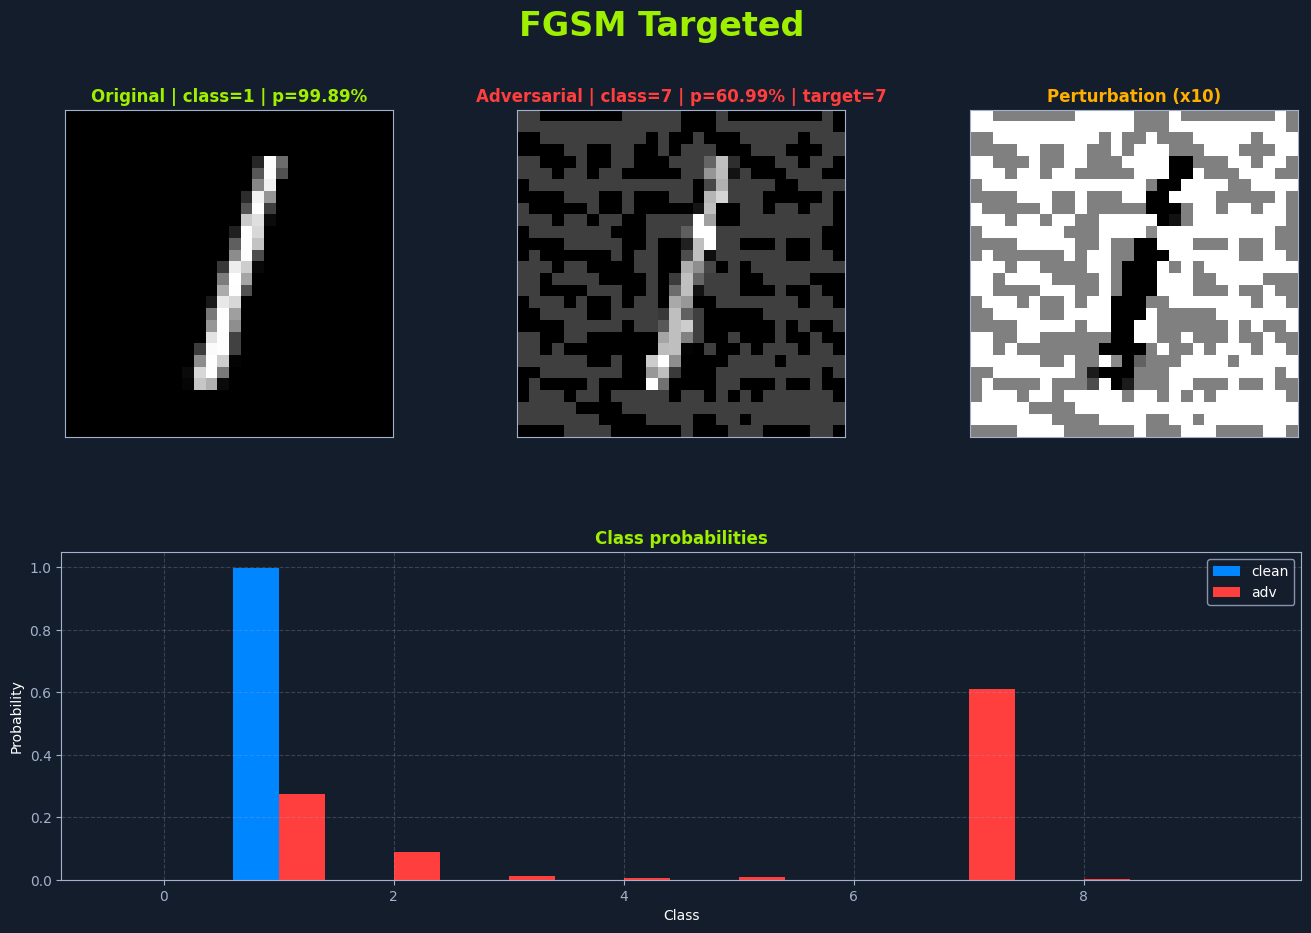

In [17]:
###########################################3
# TEST EPSILON VALUES


target_label = torch.tensor([7], device=device)

for eps_try in eps_candidates:
    x_adv = fgsm_attack(
        model,
        candidate.unsqueeze(0),
        target_label,
        epsilon=eps_try,
        targeted=True,
    )
    with torch.no_grad():
        pred = model(x_adv).argmax(dim=1).item()
    print(f"epsilon={eps_try:.2f} -> predicted {pred}")

    if pred == 7:
        success_image = candidate
        success_label = candidate_label
        success_eps = eps_try
        break

if success_image is None:
    raise RuntimeError("Targeted FGSM did not achieve 1 -> 7 within the tested epsilons.")

_ = visualize_fgsm_attack(
    model,
    success_image.detach().cpu(),
    success_label.detach().cpu(),
    success_eps,
    targeted=True,
    target_class=7,
)